# CONEXIÓN MySQL - Python

In [ ]:
import mysql.connector
from mysql.connector import Error
import pandas as pd


# --- Configuración de la conexión a la Base de Datos ---
DB_CONFIG = {
    'user': 'root',
    'password': '########', 
    'host': '127.0.0.1',
    'database': 'bdtransaction' }

try:
    with mysql.connector.connect(**DB_CONFIG) as cnx:
        if cnx.is_connected:
             
            print(f"Conexión exitosa a la base de datos: {DB_CONFIG['database']}")
        else:
            print("No se pudo establecer la conexión a la base de datos.")
            exit()

        with cnx.cursor(dictionary=True) as cursor:
            query_nombres_tablas = '''SHOW TABLES FROM bdtransaction'''
            cursor.execute( query_nombres_tablas)
            tablas_raw = cursor.fetchall()
            nombres_tablas = [list(tabla_dict.values())[0] for tabla_dict in tablas_raw]

            if not nombres_tablas:
                print("No se encontraron tablas en la base de datos.")
            else:
                print(f"Tablas encontradas: {', '.join(nombres_tablas)}")
                print("\nExtrayendo datos de cada tabla a DataFrames...")
                   
                for nombre_tabla in nombres_tablas:
                    query_tabla = f"SELECT * FROM `{nombre_tabla}`"
                    cursor.execute(query_tabla)
                    resultados = cursor.fetchall()
                    df_cargado = pd.DataFrame(resultados)

                    # Construimos el nombre de la variable que queremos (ej. 'df_clientes')
                    nombre_variable_df = f"df_{nombre_tabla}"

                    # Asignamos el DataFrame a esa variable en el espacio de nombres global.
                    # globals() es un diccionario, y podemos añadirle una nueva clave-valor.
                    # La clave es el nombre de la variable (como cadena) y el valor es el DataFrame.
                    globals()[nombre_variable_df] = df_cargado
        
        print("\n¡Proceso completado! Todos los DataFrames han sido creados como variables globales.")
        print("\n--- Resumen de DataFrames creados ---")
        for nombre_tabla in nombres_tablas:
            print(f"df_{nombre_tabla}")

except mysql.connector.Error as err:
    # Estos son errores específicos de MySQL Connector.
    if err.errno == Error.ACCESS_DENIED_ERROR:
        print("Error de autenticación: usuario o contraseña incorrectos o permisos insuficientes.")
    elif err.errno == Error.BAD_DB_ERROR:
        print(f"La base de datos '{DB_CONFIG['database']}' especificada no existe.")
    else:
        print(f"Ocurrió un error inesperado de MySQL: {err}")
except Error as e:
    # Captura otros errores generales que no son específicos de mysql.connector.Error
    print(f"Error general al conectar o consultar: {e}")
except Exception as ex:
    # Captura cualquier otro tipo de excepción inesperada.
    print(f"Ocurrió un error inesperado durante la ejecución: {ex}")

Conexión exitosa a la base de datos: bdtransaction
Tablas encontradas: card_status, companies, credit_card, products, products_transactions, transactions, users

Extrayendo datos de cada tabla a DataFrames...

¡Proceso completado! Todos los DataFrames han sido creados como variables globales.

--- Resumen de DataFrames creados ---
df_card_status
df_companies
df_credit_card
df_products
df_products_transactions
df_transactions
df_users


In [3]:
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

# NIVEL 1

## Ejercicio 1: Una variable numérica

Text(0, 0.5, 'Frecuencia')

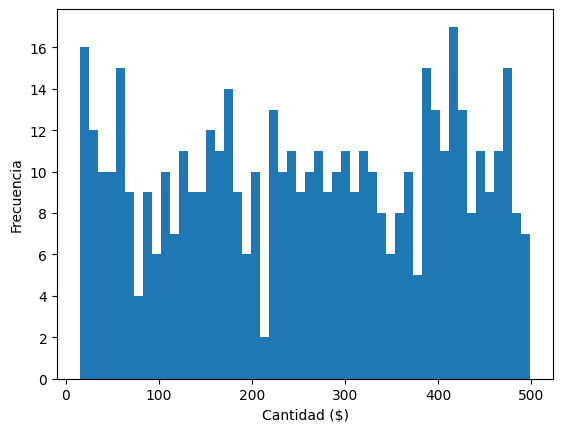

In [4]:
df_transactions['amount'] = pd.to_numeric(df_transactions['amount'], errors= 'coerce')
df_transactions_exitosas = df_transactions[df_transactions['declined'] == 0]            # Creo un dataframe filtrado a las transacciones exitosas

ventas_reales = df_transactions_exitosas.sort_values(by='amount', ascending = False)
ventas_reales['amount'].plot.hist(bins=50)
plt.xlabel('Cantidad ($)')
plt.ylabel('Frecuencia')

Se crea un histograma, ya que para una variable numérica es el tipo de gráfico más sencillo y fácil de comprender. En este gráfico se puede observar la distribución de los montos en $ de todas las transacciones completadas con éxito.

## Ejercicio 2: Dos variables numéricas.

C:\Users\irene\AppData\Local\Temp\ipykernel_63360\3867430897.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_transactions_exitosas['month_year']=df_transactions_exitosas['timestamp'].dt.strftime('%b-%Y') # Crear la columna para etiquetar el gráfico, eje x


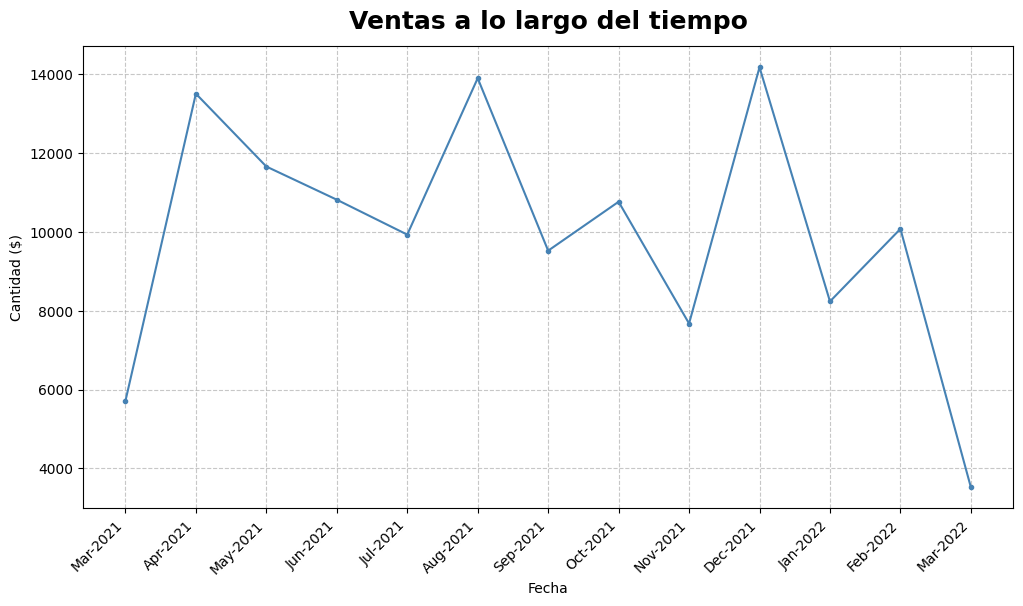

In [5]:
df_transactions_exitosas['month_year']=df_transactions_exitosas['timestamp'].dt.strftime('%b-%Y') # Crear la columna para etiquetar el gráfico, eje x

ventas_reales_tiempo = df_transactions_exitosas.groupby('month_year')['amount'].sum()

ventas_reales_tiempo_ordenado = df_transactions_exitosas.groupby('month_year', as_index=False).agg(
    total_ventas_reales=('amount', 'sum'), first_timestamp=('timestamp', 'min'))

ventas_reales_tiempo_ordenado_final = ventas_reales_tiempo_ordenado.sort_values(by='first_timestamp')

plt.figure(figsize=(12, 6))

plt.plot(ventas_reales_tiempo_ordenado_final['month_year'], ventas_reales_tiempo_ordenado_final['total_ventas_reales'],
         marker='.',
         linestyle='-',
         color='steelblue')
plt.title('Ventas a lo largo del tiempo', fontsize= 18, fontweight= 'bold', y=1.02)
plt.xlabel('Fecha')
plt.ylabel('Cantidad ($)')
plt.grid(True, linestyle='--', alpha=0.7) 
plt.xticks(rotation=45, ha='right')
plt.show()

Se selecciona el gráfico de lineas para visualizar las ventas en cada mes y facilitar ver la evolución de las mismas a lo largo del tiempo.
Se observa que no hay un comportamiento constante en las ventas, ya que suben y bajan, con picos de subidas más agudizados en los meses de abril, agosto y diciembre.

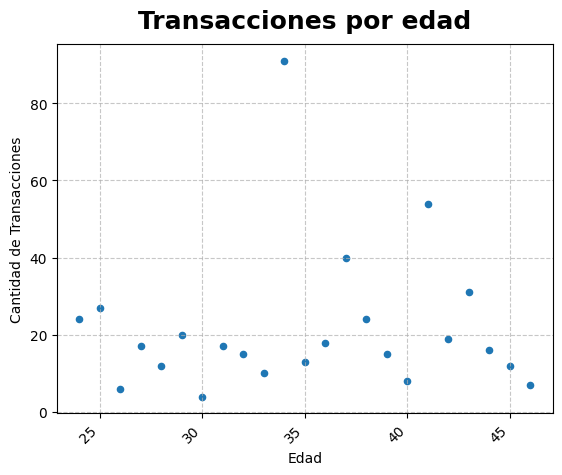

In [7]:
import datetime

fecha_actual = datetime.date.today() 
anio_actual = fecha_actual.year

df_users['birth_date'] = pd.to_datetime(df_users['birth_date'])
anio_nacimiento = df_users['birth_date'].dt.year

df_users['edad'] = anio_actual - anio_nacimiento

transacciones_exitosas_edad = pd.merge(df_transactions_exitosas, df_users, left_on='user_id', right_on='id', how= 'inner' )

clientes_edad = transacciones_exitosas_edad.groupby('edad')['id_x'].count()
clientes_edad = clientes_edad.reset_index()
clientes_edad.rename(columns={'id_x': 'cantidad_transacciones'}, inplace=True) 

clientes_edad.plot.scatter('edad', 'cantidad_transacciones')
plt.title('Transacciones por edad', fontsize= 18, fontweight= 'bold', y=1.02)
plt.xlabel('Edad')
plt.ylabel('Cantidad de Transacciones')
plt.grid(True, linestyle='--', alpha=0.7) 
plt.xticks(rotation=45, ha='right')
plt.show()


Se selecciona el gráfico de puntos para visualizar cantidad de transacciones realizadas con éxito por edad.
Se observa que hay transacciones entre usuarios de todas las edades, entre 20 y 47 años, habiendo más cantidad de transacciones en los usuarios de 34 años.

## Ejercicio 3: Una variable categórica.

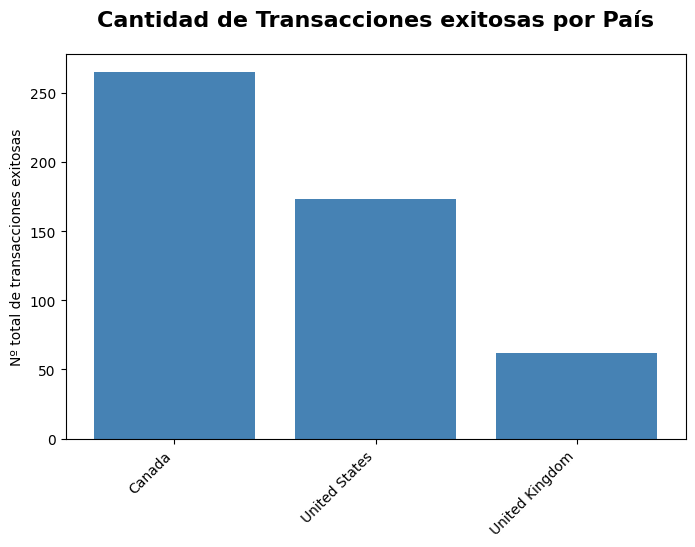

In [8]:
df_transacciones_exitosas_pais = pd.merge(df_transactions_exitosas, df_users,
                     left_on='user_id', right_on='id',
                     how='inner')

transacciones_exitosas_pais = df_transacciones_exitosas_pais.groupby('country')['id_x'].count().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(transacciones_exitosas_pais.index, transacciones_exitosas_pais.values, color='steelblue')    
plt.ylabel('Nº total de transacciones exitosas')
plt.title('Cantidad de Transacciones exitosas por País', fontsize= 16, fontweight= 'bold', y=1.05)
plt.xticks(rotation=45, ha='right')
plt.show()

Gráfico de barras para explicar la cantidad de transacciones exitosas por pais.
Se puede observar qué pais realiza más y menos transacciones, comparando entre ellos.

## Ejercicio 4: Una variable categórica y una numérica.

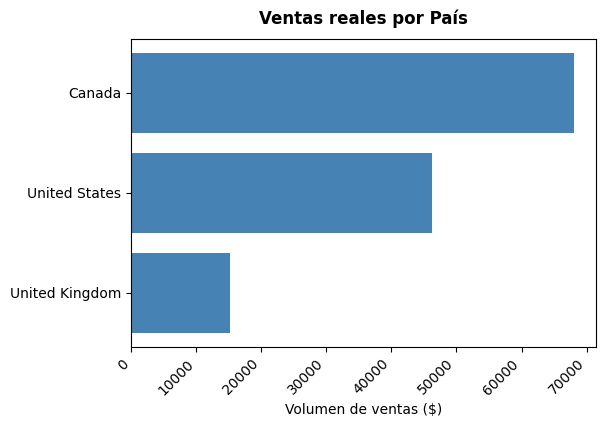

In [9]:
ventas_reales_pais = df_transacciones_exitosas_pais.groupby('country')['amount'].sum().sort_values()

plt.figure(figsize=(6,4))
plt.barh(ventas_reales_pais.index, ventas_reales_pais.values, color='steelblue')
plt.xlabel('Volumen de ventas ($)')
plt.title('Ventas reales por País', fontweight= 'bold', y=1.02)
plt.xticks(rotation=45, ha='right')
plt.show()

Un gráfico de barras para mostrar el volumen de ventas por país.
También se puede observar qué pais aporta mayores ingresos, comparando entre ellos. Si comparamos esta gráfica con la anterior, tiene bastante sentido, ya que el país con más transacciones es también el país que genera más ingresos.

## Ejercicio 5: Dos variables categóricas.

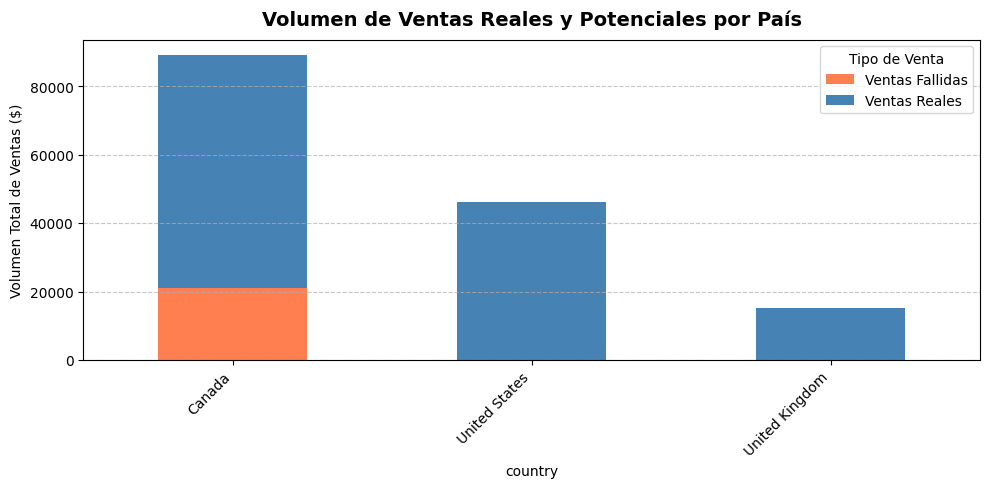

In [15]:
ventas_reales_pais

df_transactions_fallidas = df_transactions[df_transactions['declined'] == 1]

df_transactions_fallidas_pais = pd.merge(df_transactions_fallidas, df_users,
                     left_on='user_id', right_on='id',
                     how='inner')
ventas_fallidas_pais = df_transactions_fallidas_pais.groupby('country')['amount'].sum()

df_ventas_pais = pd.DataFrame({
    'Ventas Reales': ventas_reales_pais,
    'Ventas Fallidas': ventas_fallidas_pais
}).fillna(0)
df_ventas_pais = df_ventas_pais.sort_values(by='Ventas Reales', ascending=False)

plt.figure(figsize=(10,5))
df_ventas_pais[['Ventas Fallidas', 'Ventas Reales']].plot(
    kind='bar',
    stacked=True,
    ax=plt.gca(), # Esto asegura que se dibuje en la figura actual de matplotlib
    color=['coral', 'steelblue']
)

plt.title('Volumen de Ventas Reales y Potenciales por País', fontsize=14, fontweight='bold', y=1.02)
plt.ylabel('Volumen Total de Ventas ($)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo de Venta')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

Un gráfico de barras apiladas para mostrar el valor de las transacciones denegadas sobre el volumen de ventas por país, reflejando de esta manera las ganancias potenciales por país que se están dejando de obtener.
Se observa que solo hay transacciones denegadas en un país, Canadá, que además es el país con mayur número de transacciones realizadas y más ventas ($).


## Ejercicio 6: Tres variables.

In [20]:
# Hago un merge para tener las transacciones, los productos y su pais:

df_productos_pais = pd.merge(df_transacciones_exitosas_pais, df_products_transactions,
                     left_on='id_x', right_on='transaction_id',
                     how='inner')

df_nombre_productos_pais = pd.merge(df_productos_pais, df_products,
                                    left_on='product_id', right_on= 'id',
                                    how='inner')


# Creamos un df con todos los datos que interesan:
df_ventas_productos_pais = df_nombre_productos_pais.groupby(['country', 'product_name'], as_index = False).agg(total_ventas=('amount', 'sum'))


# Creamos una variable que contenga el topN de productos mas vendidos por pais:
N = 15
top_N = df_ventas_productos_pais.groupby('country', group_keys=False).head(N)


# Creamos otra variable con el resto de productos y una clave única para cada fila (país + producto) en un TEMPORAL df_productos
df_productos_temp = df_ventas_productos_pais.copy() # Trabajar en una copia para la creación de 'key'

df_productos_temp['key'] = df_productos_temp['country'].astype(str) + '_' + df_productos_temp['product_name'].astype(str)
top_N['key'] = top_N['country'].astype(str) + '_' + top_N['product_name'].astype(str) # Asegurarse que top_N también tenga 'key'

# Identificamos las claves que están en el Top N
top_N_keys = top_N['key'].tolist()

# Filtramos df_productos para obtener solo las filas cuyas claves NO están en top_N_keys
otros_productos = df_productos_temp[~df_productos_temp['key'].isin(top_N_keys)]

# Eliminamos la columna 'key' auxiliar, ya no la necesitamos
top_N = top_N.drop(columns=['key'])
otros_productos = otros_productos.drop(columns=['key'])

# Agrupamos por país y sumamos las ventas de los productos "Otros"
ventas_otros_por_pais = otros_productos.groupby('country')['total_ventas'].sum().reset_index()

# Añadimos la columna 'product_name' con el valor 'Otros'
ventas_otros_por_pais['product_name'] = 'Otros Productos'


# unificar ambos df
# Usamos pd.concat para unir los dos DataFrames verticalmente
df_final_treemap = pd.concat([top_N, ventas_otros_por_pais], ignore_index=True)

# Ordenar por país y luego por ventas descendentes.
df_final_treemap = df_final_treemap.sort_values(by=['country', 'total_ventas'], ascending=[True, False])

# El gráfico:
fig = px.treemap(df_final_treemap,
                 path=[px.Constant("Todos los Países"), 'country', 'product_name'], # Jerarquía
                 values='total_ventas',                 
                 color='total_ventas',                   
                title='Volumen de Ventas por País y Top Productos (con "Otros")',
                 hover_data={'total_ventas': ':.2s'}
                )

fig.update_layout(margin = dict(t=50, l=25, r=25, b=25)) # Ajustar márgenes
fig.show()

C:\Users\irene\AppData\Local\Temp\ipykernel_63360\3346398464.py:25: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



¿Qué productos generan más ingresos en cada pais? Variables: product, amount, country.

Selecciono un Treemap para visualizar la distribución interna de las ganancias por la venta de productos por pais. El tamaño de cada rectángulo es proporcional al total de ventas y la leyenda de color refleja el valor de esas ventas acumuladas por producto.
Se observa que en los tres paises los 15 productos que más ganancias aportan suponen más de un 50% de los ingresos para cada país, y el resto de productos suponen el otro 50% o menos. Se observan además algunos productos repetidos en el top 15 de los diferentes paises: Duel, Tully, Direwolf Stannis, Tarly Stark...

## Ejercicio 7: Graficar un Pairplot.

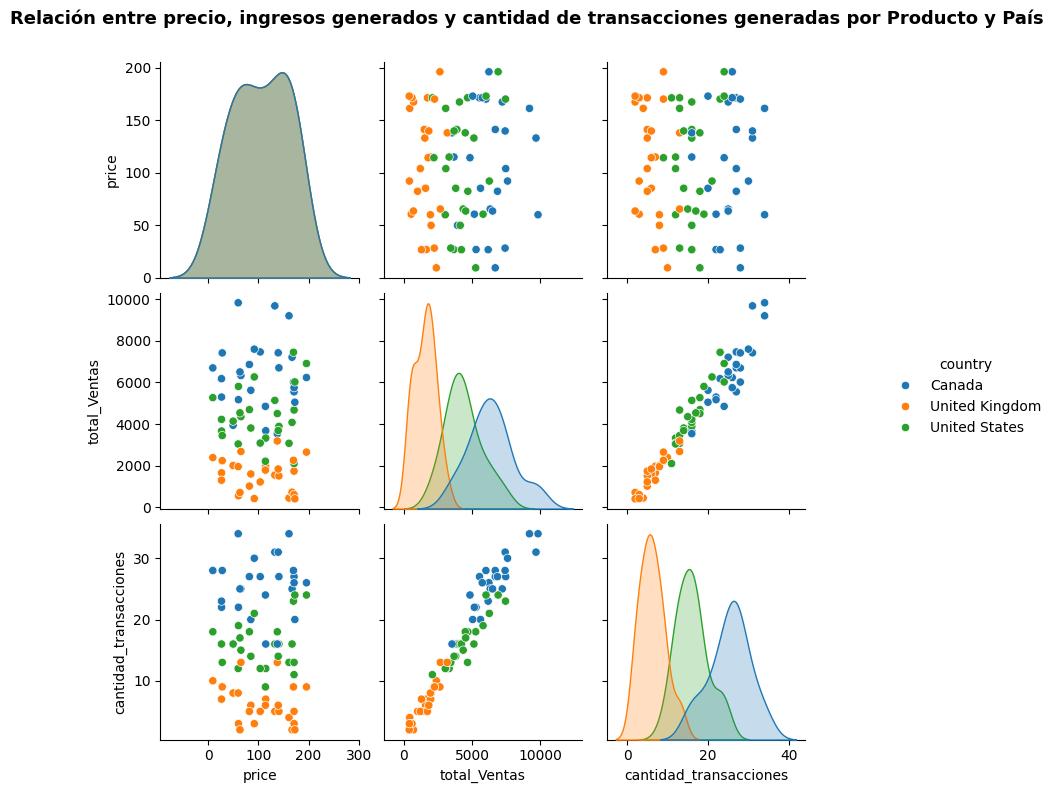

In [21]:
df_pairplot = df_nombre_productos_pais.copy()
df_pairplot = df_pairplot[df_pairplot['declined'] ==0]
df_pairplot = df_pairplot[['transaction_id','country','product_name','price','amount']]

df_pairplot = df_pairplot.groupby(['product_name', 'price', 'country'], as_index=False).agg(total_Ventas=('amount', 'sum'), cantidad_transacciones= ('transaction_id', 'count'))


sns.pairplot(df_pairplot, vars=['price', 'total_Ventas', 'cantidad_transacciones'], hue='country')
plt.suptitle('Relación entre precio, ingresos generados y cantidad de transacciones generadas por Producto y País', fontsize=13, fontweight = 'bold', y=1.05)
plt.show()

¿Qué productos tienen un alto precio y generan muchas ventas?¿Qué productos generan muchas transacciones(alta demanda)?

Variables para el Pair Plot: Precio, total de ventas y Cantidad_transacciones. Cada punto en el pair plot sería un producto, habiendo 3 colores para cada uno de los 3 paises para ver si, por ejemplo, los productos caros venden más en un país que en otro.

No se observa una relación clara entre cantidad de productos vendidos y precio de productos. En los 3 países se venden productos de todo el rango de precios. Si que se observa lo que veniamos viend hasta ahora, que Canadá genera mucha más demanda de productos y tambien más beneficio economico para la empresa. En cuanto a la cantidad de transacciones generadas por producto si observamos que en Canadá hay 3 productos que generan el máximo de transacciones y de ingresos. Sería interesante ver qué productos son estos que generan una alta demanda y alto volumen de ventas($).

# NIVEL 2

## Exercici 1: Correlació de totes les variables numèriques.

Matriz de Correlación calculada:
                           price  total_Ventas  cantidad_transacciones
price                   1.000000      0.018169                0.015769
total_Ventas            0.018169      1.000000                0.971409
cantidad_transacciones  0.015769      0.971409                1.000000
--------------------------------------------------


<Figure size 1000x800 with 0 Axes>

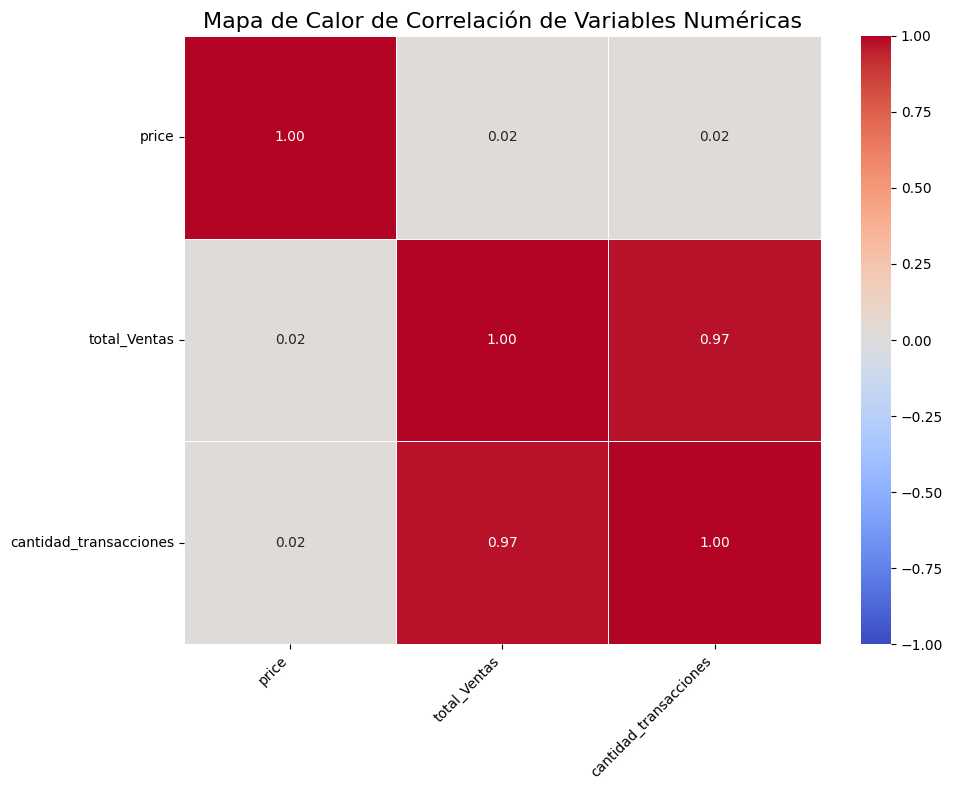

In [22]:
df_correlacion = df_pairplot.copy().drop(columns=['country', 'product_name'])

matriz_correlacion = df_correlacion.corr()

print("Matriz de Correlación calculada:")
print(matriz_correlacion)
print("-" * 50)

plt.figure(figsize=(10,8))
plt.figure(figsize=(10,8))
sns.heatmap(matriz_correlacion,
            annot = True,      # Para mostrar los valores de correlación en las celdas
            cmap = 'coolwarm',
            vmin=-1, vmax=1,
            fmt = '.2f', # Para el formato de numeros a solo 2 decimales
            linewidths = 0.5)
plt.title('Mapa de Calor de Correlación de Variables Numéricas', fontsize = 16)
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Para la correlación de las variables numéricas el mapa de calor es la herramienta ideal, ya que compara y muestra la correlacion entre todas y cada una de ellas. 

En este caso se puede observar que la correlación entre transacciones y ganancias es alta y positiva, lo cual implica que a mayor numer de transacciones, se obtienen mayores ganancias, lo cual ya es lógico de por sí. En cuanto a la relación entre la cantidad de transacciones y el precio del producto es practicamente nula, lo cual implica que el precio del producto no influye en su mayor o menor demanda por parte de los clientes.  Lo mismo ocurre con la relación entre el precio del producto y el total de ventas, lo que implica que los precios de lo productos no repercuten en la variabilidad de las ventas. Da igual el precio que tenga cada producto, más o menos todo se venden de forma homogenea.

## Exercici 2: Implementa un jointplot.

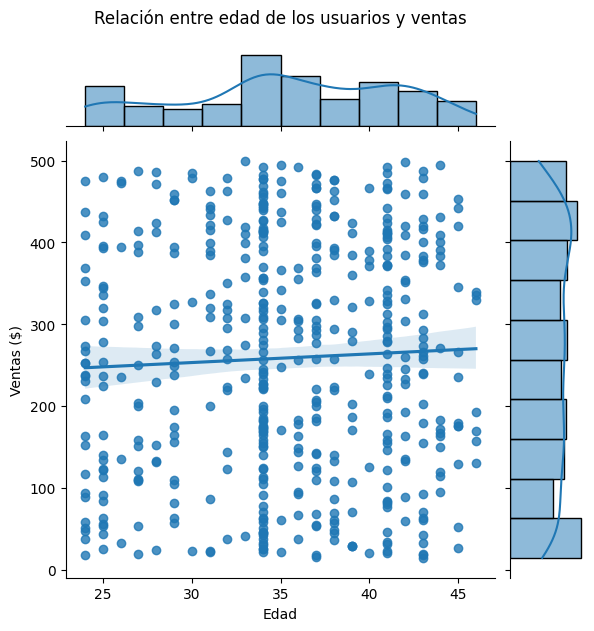

In [23]:
ventas_edad = transacciones_exitosas_edad[['id_x', 'edad', 'amount']]
ventas_edad.groupby('edad')['amount'].sum()

sns.jointplot(data=ventas_edad, x='edad', y='amount', kind='reg')
plt.title('Relación entre edad de los usuarios y ventas', y=1.25)
plt.xlabel('Edad')
plt.ylabel('Ventas ($)')
plt.show()

Se observa que hay usuarios de todas las edades, con una mequeña mayoría cercana a los 35 años. No hay relación entre la edad y el gasto de los usuarios.

# NIVEL 3

## Ejercicio 1: Implementa un violinplot combinado con otro tipo de gráfico.

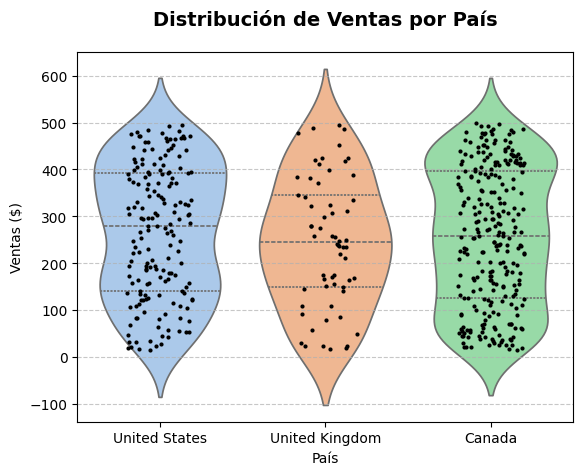

In [24]:
sns.violinplot(data=df_transacciones_exitosas_pais, x='country', y='amount', inner='quartile', palette='pastel', hue='country')
sns.stripplot(data= df_transacciones_exitosas_pais, x= 'country', y='amount', color='black', size=3, jitter=0.2)
plt.title('Distribución de Ventas por País', fontsize = 14, fontweight= 'bold', y = 1.05)
plt.xlabel('País')
plt.ylabel('Ventas ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Ejercicio 2: Genera un FacetGrid para visualizar múltiples aspectos de datos simultáneamente.

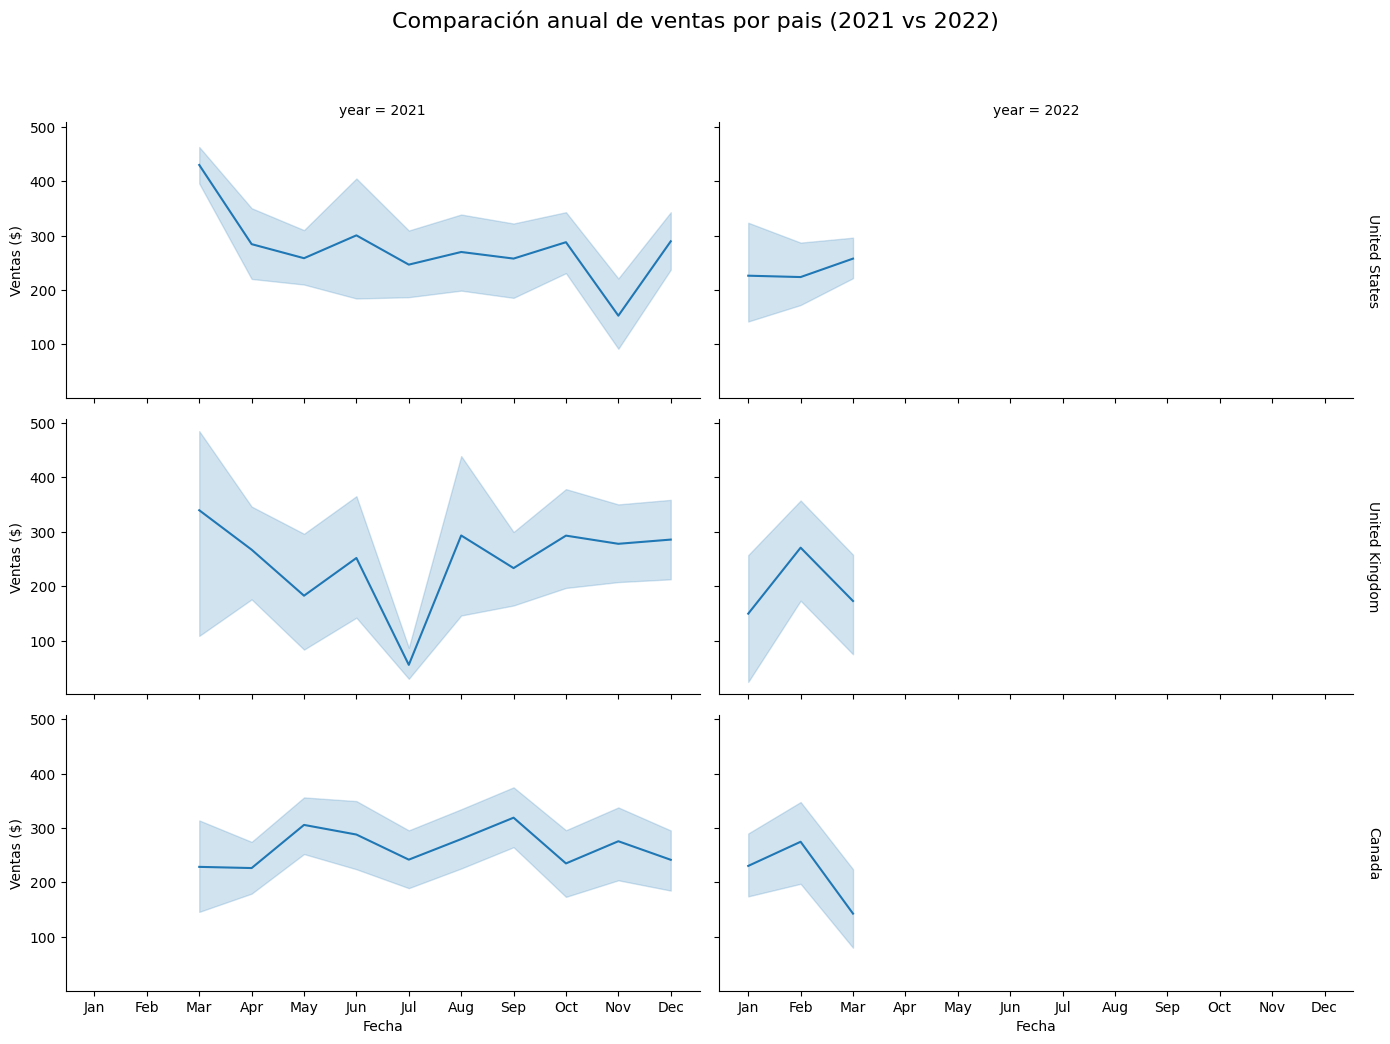

In [25]:
df_transacciones_exitosas_pais['year']= df_transacciones_exitosas_pais['timestamp'].dt.year

df_transacciones_exitosas_pais['month_name'] = df_transacciones_exitosas_pais['timestamp'].dt.strftime('%b')

from pandas.api.types import CategoricalDtype
meses_ordenados = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_transacciones_exitosas_pais['month_name'] = pd.Categorical(
    df_transacciones_exitosas_pais['month_name'],
    categories=meses_ordenados,
    ordered=True
)

grafico = sns.relplot(data=df_transacciones_exitosas_pais,
            x='month_name',
            y='amount',
            kind='line',
            col='year',
            row='country',
            height=3.5,
            aspect=2,
            facet_kws={'margin_titles': True}
        )

grafico.set_axis_labels("Fecha", "Ventas ($)")
grafico.set_titles(row_template="{row_name}")
plt.suptitle("Comparación anual de ventas por pais (2021 vs 2022)", y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()